# PyTorch: Theory & Hands-On Projects

A complete, self-contained notebook covering PyTorch fundamentals — from tensors and autograd to full training pipelines — with runnable code for every concept and three end-to-end mini-projects.

**Contents**
1. What is PyTorch?
2. Tensors: Theory & Creation
3. Mathematical Operations on Tensors
4. Shapes, Reshaping & Dimensions
5. Autograd: Gradients in PyTorch
6. Project 1 — Linear Regression (Electricity Bills)
7. Datasets & DataLoaders
8. Building a Neural Network (`nn.Module`)
9. Project 2 — Digit Classification (MNIST-style digits)
10. Project 3 — Challenge: Iris Flower Classification
11. Wrap-up & Key Takeaways


## 1. What is PyTorch?

**PyTorch** is a Python-based, open-source deep learning library designed to make building and training neural networks intuitive and flexible. It is used across:

- **Deep Learning Research** — its flexibility and dynamic computation graph make it ideal for experimenting with novel architectures.
- **Natural Language Processing (NLP)** — text classification, machine translation, sentiment analysis (transformers).
- **Computer Vision** — image classification, object detection, segmentation.

### PyTorch's core strengths

1. **Dynamic computation graphs** ("define-by-run") — the graph is built on the fly as operations execute, instead of being declared upfront. This makes debugging and experimenting far easier, since you can use ordinary Python control flow (`if`/`for`/`while`) inside your model.
2. **Tensor operations with GPU acceleration** — tensors are like NumPy arrays but can be moved to a GPU with `.to('cuda')` for massive speedups.
3. **Rich neural-network API (`torch.nn`)** — ready-made layers (convolutions, RNNs, linear layers) and loss functions, assembled into custom `nn.Module` subclasses.
4. **Automatic differentiation (autograd)** — tracks every tensor operation so gradients can be computed automatically during backpropagation. No manual calculus required.
5. **Ecosystem and community** — `torchvision`, `torchtext`, Hugging Face, and a large research community.

### The typical PyTorch workflow

1. Define your model by subclassing `torch.nn.Module`.
2. Prepare `DataLoader`s to feed input batches.
3. Choose an optimizer (e.g. `torch.optim.SGD` or `Adam`) and a loss function.
4. Run a **training loop**: forward pass → compute loss → `.backward()` → update parameters.

### PyTorch vs. TensorFlow

| Feature | PyTorch | TensorFlow |
|---|---|---|
| **Ease of Use** | Pythonic API, intuitive, beginner-friendly | More complex but powerful for advanced applications |
| **Community Support** | Strong academic/research backing | Large industry adoption |
| **Production Deployment** | TorchServe, TorchScript | TensorFlow Serving, TensorFlow Lite |
| **Popularity in Academia** | Widely used for research | Traditionally favored in industry |
| **Library Ecosystem** | `torchvision`, Hugging Face | Keras, TFX |

PyTorch's combination of flexibility, ease of use, and community support has made it a leading choice for both research and production deep learning.

### Dynamic vs. static computation graphs

- **Static graph**: declare the entire network/computation first, compile it, *then* run data through it. Modifying the graph at runtime is cumbersome.
- **Dynamic graph (PyTorch)**: the graph is built step by step, *as each operation runs*. You get immediate feedback — you can print an activation or plot it mid-training-loop — and you can branch or restructure computation per input sample. This agility is why PyTorch is so popular for research.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


PyTorch version: 2.14.0+cu130
CUDA available: False


## 2. Tensors: Theory & Creation

A **tensor** is a way to organize numbers in one or more dimensions — a generalization of familiar structures:

- A **scalar** (e.g. `5`) is a **0-dimensional** tensor.
- A **vector** (e.g. `[1, 2, 3]`) is a **1-dimensional** tensor.
- A **matrix** (e.g. `[[1, 2], [3, 4]]`) is a **2-dimensional** tensor.
- Stacking matrices (e.g. a batch of images) gives a **3-dimensional** tensor, and so on.

Key points:
- Dimensions are often called **axes** or **ranks**.
- Each axis adds a level of nesting: vectors nest scalars, matrices nest vectors, etc.
- Tensors let us handle complex data (color images, video, batches) uniformly.

### Tensors vs. NumPy arrays

PyTorch tensors behave like NumPy arrays (same indexing/slicing rules), but add:
- Native **GPU acceleration** (`.to('cuda')`)
- Integration with PyTorch's deep-learning modules (`torch.nn`)
- Compatibility with **autograd** (automatic differentiation for backpropagation)

### Creating tensors from data

`torch.tensor(data)` converts a Python list/nested-list (or NumPy array) into a PyTorch tensor. It infers the **shape** from the nesting/lengths and assigns a default `dtype`.


In [2]:
# Basic tensor creation from a nested list
data = [[1, 2], [3, 4]]
tensor = torch.tensor(data)
print(tensor)
print("shape:", tensor.shape, "| dtype:", tensor.dtype)


tensor([[1, 2],
        [3, 4]])
shape: torch.Size([2, 2]) | dtype: torch.int64


In [3]:
# --- Practical task: build a 3D tensor directly, in one line, no intermediate variable ---
tensor_3d = torch.tensor([[[1, 2], [3, 4]], [[5, 6], [7, 8]], [[9, 10], [11, 12]]])
print(tensor_3d)
print("shape:", tensor_3d.shape)  # (3, 2, 2): 3 matrices of 2x2


tensor([[[ 1,  2],
         [ 3,  4]],

        [[ 5,  6],
         [ 7,  8]],

        [[ 9, 10],
         [11, 12]]])
shape: torch.Size([3, 2, 2])


### Built-in tensor-creation functions

| Function | Produces |
|---|---|
| `torch.zeros(*size)` | Tensor of all zeros (placeholders / initial biases) |
| `torch.ones(*size)` | Tensor of all ones (neutral multiplier / initial weights) |
| `torch.arange(start, end, step)` | 1D sequence; `end` is **exclusive** |
| `torch.linspace(start, end, steps)` | `steps` evenly spaced values; **both endpoints included** |
| `torch.zeros_like(x)` / `torch.ones_like(x)` | Same shape & dtype as `x`, filled with 0s/1s |


In [4]:
# Zeros and ones
print("zeros(4,2):\n", torch.zeros(4, 2))
print("ones(3,3):\n", torch.ones(3, 3))

# arange: end exclusive, fixed step
print("arange(0,10,step=2):", torch.arange(0, 10, step=2))

# linspace: fixed number of points, both endpoints included
print("linspace(0,1,steps=5):", torch.linspace(0, 1, steps=5))

# "like" variants
x = torch.tensor([[1, 2, 3], [4, 5, 6]])
print("zeros_like(x):\n", torch.zeros_like(x))
print("ones_like(x):\n", torch.ones_like(x))


zeros(4,2):
 tensor([[0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.]])
ones(3,3):
 tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]])
arange(0,10,step=2): tensor([0, 2, 4, 6, 8])
linspace(0,1,steps=5): tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])
zeros_like(x):
 tensor([[0, 0, 0],
        [0, 0, 0]])
ones_like(x):
 tensor([[1, 1, 1],
        [1, 1, 1]])


In [5]:
# --- Practical challenge: Initializing Tensors ---
tensor_1 = torch.zeros(2, 3)                 # 2x3 tensor of zeros
tensor_2 = torch.arange(1, 11)               # 1..10 inclusive
tensor_3 = torch.linspace(2, 4, 10)          # 10 evenly spaced values in [2, 4]

print("tensor_1:\n", tensor_1)
print("tensor_2:", tensor_2)
print("tensor_3:", tensor_3)


tensor_1:
 tensor([[0., 0., 0.],
        [0., 0., 0.]])
tensor_2: tensor([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])
tensor_3: tensor([2.0000, 2.2222, 2.4444, 2.6667, 2.8889, 3.1111, 3.3333, 3.5556, 3.7778,
        4.0000])


### Random tensors

Random initialization is the most common real-world use case for random tensors (weights, biases).

| Function | Distribution |
|---|---|
| `torch.rand(*size)` | Uniform `[0, 1)` |
| `torch.randint(low, high, size)` | Discrete uniform integers in `[low, high)` |
| `torch.randn(*size)` | Standard normal (mean 0, std 1) |

> **Note:** in real neural networks you would **not** use plain random integers or raw uniform `[0,1)` values for weights — you'd use small, zero-mean values (e.g. **Xavier/Glorot** or **He initialization**) to keep activations and gradients in a healthy numerical range. `torch.nn.init.xavier_uniform_` etc. do this for you.


In [6]:
torch.manual_seed(42)  # for reproducibility

print("Uniform [0,1) 6x8:\n", torch.rand(6, 8))
print("\nStandard normal 2x2:\n", torch.randn(2, 2))
print("\nRandom ints [0,11) 2x2:\n", torch.randint(0, 11, (2, 2)))


Uniform [0,1) 6x8:
 tensor([[0.8823, 0.9150, 0.3829, 0.9593, 0.3904, 0.6009, 0.2566, 0.7936],
        [0.9408, 0.1332, 0.9346, 0.5936, 0.8694, 0.5677, 0.7411, 0.4294],
        [0.8854, 0.5739, 0.2666, 0.6274, 0.2696, 0.4414, 0.2969, 0.8317],
        [0.1053, 0.2695, 0.3588, 0.1994, 0.5472, 0.0062, 0.9516, 0.0753],
        [0.8860, 0.5832, 0.3376, 0.8090, 0.5779, 0.9040, 0.5547, 0.3423],
        [0.6343, 0.3644, 0.7104, 0.9464, 0.7890, 0.2814, 0.7886, 0.5895]])

Standard normal 2x2:
 tensor([[ 0.2815,  0.0562],
        [ 0.5227, -0.2384]])

Random ints [0,11) 2x2:
 tensor([[4, 7],
        [4, 6]])


In [7]:
# --- Practical challenge: Initializing Weights & Biases for a small NN ---
torch.manual_seed(42)

weights_layer1 = torch.rand(3, 4)                    # uniform [0,1) weights, layer 1
biases_layer1  = torch.zeros(1, 4)                   # zero biases, layer 1
weights_layer2 = torch.randint(-5, 6, (4, 2))        # integer weights in [-5, 5], layer 2 (didactic only)

print("Weights layer 1:\n", weights_layer1)
print("Biases layer 1:\n", biases_layer1)
print("Weights layer 2:\n", weights_layer2)


Weights layer 1:
 tensor([[0.8823, 0.9150, 0.3829, 0.9593],
        [0.3904, 0.6009, 0.2566, 0.7936],
        [0.9408, 0.1332, 0.9346, 0.5936]])
Biases layer 1:
 tensor([[0., 0., 0., 0.]])
Weights layer 2:
 tensor([[-2, -1],
        [-3, -5],
        [-1, -2],
        [ 1,  4]])


## 3. Mathematical Operations with Tensors

### Element-wise operations
Applied to each element individually — `+`, `-`, `*`, `/` all work like NumPy.

### Matrix operations
- `torch.matmul(a, b)` or `a @ b` — true matrix multiplication: `(a@b)[i,j] = Σₖ a[i,k]·b[k,j]`
- `a * b` — element-wise (Hadamard) product, **not** matrix multiplication
- `torch.dot(a, b)` — inner product of two 1D vectors only

### Aggregations
`tensor.sum(dim=...)`, `.mean(dim=...)`, `.max(dim=...)` reduce along an axis.
- `dim=0` collapses **rows** (reduces down columns)
- `dim=1` collapses **columns** (reduces across rows)
- `keepdim=True` keeps the reduced axis as size 1 (useful for broadcasting, e.g. row-wise softmax)
- `.max(dim=...)` returns a **tuple** `(values, indices)`


In [8]:
a = torch.tensor([1, 2, 3])
b = torch.tensor([4, 5, 6])

print("Addition:", a + b)
print("Subtraction:", a - b)
print("Element-wise multiplication:", a * b)
print("Division:", a / b)


Addition: tensor([5, 7, 9])
Subtraction: tensor([-3, -3, -3])
Element-wise multiplication: tensor([ 4, 10, 18])
Division: tensor([0.2500, 0.4000, 0.5000])


In [9]:
x = torch.tensor([[1, 2], [3, 4]])
y = torch.tensor([[5, 6], [7, 8]])

print("Matrix multiplication (matmul):\n", torch.matmul(x, y))
print("Matrix multiplication (@):\n", x @ y)
print("Element-wise product (*):\n", x * y)

v1 = torch.tensor([1, 2, 3])
v2 = torch.tensor([4, 5, 6])
print("Dot product:", torch.dot(v1, v2))


Matrix multiplication (matmul):
 tensor([[19, 22],
        [43, 50]])
Matrix multiplication (@):
 tensor([[19, 22],
        [43, 50]])
Element-wise product (*):
 tensor([[ 5, 12],
        [21, 32]])
Dot product: tensor(32)


In [10]:
tensor = torch.tensor([[1, 2, 3], [4, 5, 6]])
print("Sum along rows (dim=1):", tensor.sum(dim=1))
print("Sum along columns (dim=0):", tensor.sum(dim=0))
print("Sum along rows, keepdim=True:\n", tensor.sum(dim=1, keepdim=True))


Sum along rows (dim=1): tensor([ 6, 15])
Sum along columns (dim=0): tensor([5, 7, 9])
Sum along rows, keepdim=True:
 tensor([[ 6],
        [15]])


In [11]:
# --- Practical challenge: row/column aggregations + normalization ---
tensor = torch.tensor([[3, 7, 1], [2, 5, 9], [8, 6, 4]]).float()

row_sum = tensor.sum(dim=1, keepdim=True)     # sum of each row, dims retained
column_mean = tensor.mean(dim=0)               # mean of each column
row_max = tensor.max(dim=1)[0]                 # max value of each row
overall_sum = tensor.sum()                     # scalar: sum of everything
normalized_tensor = tensor / overall_sum       # normalize by overall sum

print("Original tensor:\n", tensor)
print("Row sum:\n", row_sum)
print("Column mean:\n", column_mean)
print("Row max:\n", row_max)
print("Normalized tensor:\n", normalized_tensor)


Original tensor:
 tensor([[3., 7., 1.],
        [2., 5., 9.],
        [8., 6., 4.]])
Row sum:
 tensor([[11.],
        [16.],
        [18.]])
Column mean:
 tensor([4.3333, 6.0000, 4.6667])
Row max:
 tensor([7., 9., 8.])
Normalized tensor:
 tensor([[0.0667, 0.1556, 0.0222],
        [0.0444, 0.1111, 0.2000],
        [0.1778, 0.1333, 0.0889]])


## 4. Shapes, Reshaping & Dimensions

- `.shape` returns a `torch.Size` describing the size along each axis.
- **`.view(*shape)`** reinterprets the *same underlying memory* with a new shape — no copy, but requires the tensor to be contiguous. Changing one changes the other.
- **`.reshape(*shape)`** works like `.view()` but will copy data if the tensor isn't contiguous, and is generally safer.
- **`-1`** in a shape argument tells PyTorch to infer that dimension automatically.
- **`.unsqueeze(dim)`** inserts a new size-1 axis at `dim`.
- **`.squeeze(dim)`** removes a size-1 axis at `dim` (or all size-1 axes if no argument is given).


In [12]:
tensor = torch.arange(12)
print("Original:", tensor, "shape:", tensor.shape)

reshaped = tensor.view(4, 3)          # shares memory with `tensor`
print("Viewed as 4x3:\n", reshaped)

reshaped[0, 0] = 999                  # mutating the view...
print("...also mutates the original:", tensor)


Original: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11]) shape: torch.Size([12])
Viewed as 4x3:
 tensor([[ 0,  1,  2],
        [ 3,  4,  5],
        [ 6,  7,  8],
        [ 9, 10, 11]])
...also mutates the original: tensor([999,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11])


In [13]:
t = torch.arange(18)
inferred = t.view(3, -1)   # PyTorch infers the second dimension: 18 / 3 = 6
print(inferred.shape)      # torch.Size([3, 6])


torch.Size([3, 6])


In [14]:
# --- Practical challenge: reshape / view / unsqueeze / squeeze ---
torch.manual_seed(0)
tensor = torch.randint(1, 10, (3, 4))

reshaped_tensor = tensor.reshape(2, 6)          # 3x4 -> 2x6
view_tensor = reshaped_tensor.view(4, 3)        # a 4x3 view of the same data
unsqueezed_tensor = reshaped_tensor.unsqueeze(2)  # insert axis at position 2 -> (2,6,1)
squeezed_tensor = unsqueezed_tensor.squeeze(2)    # remove it again -> (2,6)

print("Original:\n", tensor)
print("Reshaped (2x6):\n", reshaped_tensor)
print("View (4x3):\n", view_tensor)
print("Unsqueezed shape:", unsqueezed_tensor.shape)
print("Squeezed shape:", squeezed_tensor.shape)


Original:
 tensor([[9, 1, 3, 7],
        [8, 7, 8, 2],
        [2, 1, 9, 3]])
Reshaped (2x6):
 tensor([[9, 1, 3, 7, 8, 7],
        [8, 2, 2, 1, 9, 3]])
View (4x3):
 tensor([[9, 1, 3],
        [7, 8, 7],
        [8, 2, 2],
        [1, 9, 3]])
Unsqueezed shape: torch.Size([2, 6, 1])
Squeezed shape: torch.Size([2, 6])


## 5. Gradients in PyTorch (Autograd)

A **gradient** is the vector of all partial derivatives of a function with respect to its inputs:

$$\nabla f = \left[\frac{\partial f}{\partial x}, \frac{\partial f}{\partial y}, \frac{\partial f}{\partial z}\right]$$

It tells you the direction of steepest increase of `f`, and how fast `f` grows in that direction. In machine learning, gradients tell you how to adjust each model parameter to increase or decrease a loss.

### How autograd works
1. Create a tensor with `requires_grad=True` — PyTorch will now track every operation on it.
2. Perform a sequence of operations — PyTorch builds a **computation graph** on the fly.
3. Call `.backward()` on a **scalar** result — PyTorch walks the graph backward (reverse-mode autodiff / the chain rule) and fills `.grad` on every leaf tensor with `requires_grad=True`.
4. Read gradients from `tensor.grad`.

**Gotchas:**
- `.backward()` doesn't *return* gradients — it fills `.grad` in place.
- Gradients **accumulate** across multiple `.backward()` calls — you must zero them (`optimizer.zero_grad()`) between training steps.
- Wrap **inference/evaluation** code in `torch.no_grad()` to save memory (you should *not* wrap `.backward()` itself in `no_grad()`).


In [15]:
x = torch.tensor(2.0, requires_grad=True)
y = x ** 2 + 3 * x + 1     # y = x^2 + 3x + 1  => dy/dx = 2x + 3
y.backward()
print("x:", x.item(), "| y:", y.item(), "| dy/dx:", x.grad.item())  # expect 2*2+3 = 7


x: 2.0 | y: 11.0 | dy/dx: 7.0


In [16]:
# Multi-step backpropagation through several operations
x = torch.tensor([[1.0, 2.0, 3.0], [3.0, 2.0, 1.0]], requires_grad=True)

y = 6 * x + 3
z = 10 * y ** 2
output_mean = z.mean()

output_mean.backward()
print("Output:", output_mean.item())
print("Gradient of x:\n", x.grad)


Output: 2490.0
Gradient of x:
 tensor([[180.0000, 300.0000, 420.0000],
        [420.0000, 300.0000, 180.0000]])


In [17]:
# --- Practical challenge: gradient of a loss w.r.t. a weight matrix ---
torch.manual_seed(42)

W = torch.rand(1, 3, requires_grad=True)                     # weights, tracked
X = torch.tensor([[1.0, 2.0], [3.0, 4.0], [5.0, 6.0]])        # input, shape (3,2)
Y_target = torch.tensor([[10.0, 20.0]])

Y = torch.matmul(W, X)                       # (1,3) @ (3,2) -> (1,2)
loss = ((Y - Y_target) ** 2).mean()          # mean squared error
loss.backward()

print("Prediction Y:", Y)
print("Loss:", loss.item())
print("Gradient of W:\n", W.grad)


Prediction Y: tensor([[5.5416, 7.7217]], grad_fn=<MmBackward0>)
Loss: 85.31653594970703
Gradient of W:
 tensor([[-29.0149, -62.4883, -95.9616]])


Notice the gradient values: they show exactly which direction each weight should move (via gradient *descent*) to reduce the loss — this is the mathematical heart of every neural-network training loop.

## 6. Project 1 — Linear Regression

**Goal:** predict a household's electricity bill from its number of appliances, using `nn.Linear`, `nn.MSELoss`, and `optim.SGD`.

> The original course dataset is hosted on an external CDN that isn't reachable from this environment, so we generate a synthetic dataset with the same structure and a realistic linear relationship + noise. The modeling code is identical to what you'd use on real data.


In [18]:
# Generate a synthetic "electricity bills" dataset:
# bill ~= 15 * num_appliances + 20 + noise
np.random.seed(42)
n_samples = 200
num_appliances = np.random.randint(1, 20, size=n_samples).astype(float)
electricity_bill = 15 * num_appliances + 20 + np.random.normal(0, 15, size=n_samples)

bills_df = pd.DataFrame({
    "Number of Appliances": num_appliances,
    "Electricity Bill": electricity_bill
})
bills_df.head()


,Number of Appliances,Electricity Bill
0,7.0,142.538115
1,15.0,258.099755
2,11.0,188.084752
3,8.0,118.347750
4,7.0,109.584337


In [19]:
# Prepare tensors: PyTorch models expect 2D input of shape [N, features]
X = torch.tensor(bills_df["Number of Appliances"].values).float().reshape(-1, 1)
Y = torch.tensor(bills_df["Electricity Bill"].values).float().reshape(-1, 1)

# Define the linear regression model: y = w*x + b
model = nn.Linear(in_features=1, out_features=1)

loss_fn = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.005)

epochs = 100
losses = []
for epoch in range(epochs):
    # 1. Forward pass
    Y_pred = model(X)
    loss = loss_fn(Y_pred, Y)

    # 2. Backward pass
    optimizer.zero_grad()   # reset gradients (they accumulate by default!)
    loss.backward()         # compute gradients via autograd

    # 3. Update parameters
    optimizer.step()

    losses.append(loss.item())
    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

print(f"\nTrained weight: {model.weight.item():.4f}")
print(f"Trained bias:   {model.bias.item():.4f}")


Epoch [20/100], Loss: 291.6050
Epoch [40/100], Loss: 285.2508
Epoch [60/100], Loss: 279.5194
Epoch [80/100], Loss: 274.3500
Epoch [100/100], Loss: 269.6873

Trained weight: 16.3246
Trained bias:   4.8151


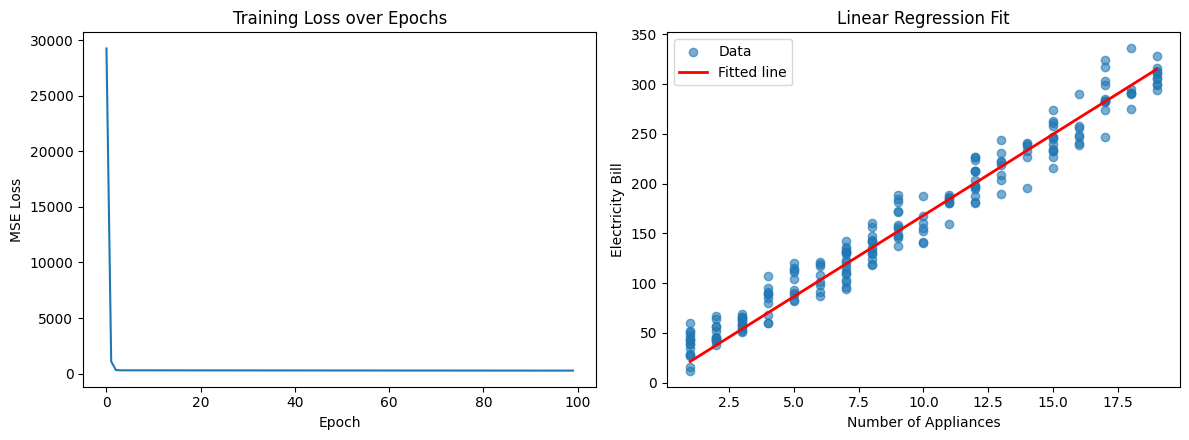

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(losses)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].set_title("Training Loss over Epochs")

axes[1].scatter(X.numpy(), Y.numpy(), alpha=0.6, label="Data")
with torch.no_grad():
    x_line = torch.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    y_line = model(x_line)
axes[1].plot(x_line.numpy(), y_line.numpy(), color="red", linewidth=2, label="Fitted line")
axes[1].set_xlabel("Number of Appliances")
axes[1].set_ylabel("Electricity Bill")
axes[1].set_title("Linear Regression Fit")
axes[1].legend()

plt.tight_layout()
plt.show()


### Mini-challenge: Hours Studied → Test Score

Same recipe, different data: predict a test score from hours studied.


In [21]:
# Synthetic "hours studied -> test score" dataset
np.random.seed(7)
hours = np.random.uniform(0, 10, size=120)
scores = 9 * hours + 5 + np.random.normal(0, 8, size=120)
scores = np.clip(scores, 0, 100)

X_tensor = torch.tensor(hours, dtype=torch.float32).reshape(-1, 1)
Y_tensor = torch.tensor(scores, dtype=torch.float32).reshape(-1, 1)

model2 = nn.Linear(1, 1)
criterion = nn.MSELoss()
optimizer2 = optim.SGD(model2.parameters(), lr=0.01)

epochs = 100
for epoch in range(epochs):
    predictions = model2(X_tensor)
    loss = criterion(predictions, Y_tensor)

    optimizer2.zero_grad()
    loss.backward()
    optimizer2.step()

    if (epoch + 1) % 25 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

print(f"\nTrained weight: {model2.weight.item():.4f} (points per hour studied)")
print(f"Trained bias:   {model2.bias.item():.4f}")


Epoch [25/100], Loss: 55.3731
Epoch [50/100], Loss: 54.8931
Epoch [75/100], Loss: 54.5057
Epoch [100/100], Loss: 54.1929

Trained weight: 9.3289 (points per hour studied)
Trained bias:   2.2546


## 7. Working with Datasets: `TensorDataset` & `DataLoader`

For efficient batch processing, shuffling, and iteration, PyTorch provides:
- **`TensorDataset(features, targets)`** — pairs each feature row with its label; indexing returns `(features[i], targets[i])`.
- **`DataLoader(dataset, batch_size, shuffle=True)`** — yields shuffled mini-batches automatically.

**Why shuffle?** If training data has an unintended order (e.g. grouped by class), the model can pick up on that ordering instead of the true underlying pattern. Shuffling before each epoch ensures every batch is a representative random sample.

We'll use the classic **Wine** dataset (13 chemical measurements → wine class) via scikit-learn.


In [22]:
from sklearn.datasets import load_wine

wine = load_wine()
features = wine.data
target = wine.target

wine_dataset = TensorDataset(
    torch.tensor(features, dtype=torch.float32),
    torch.tensor(target, dtype=torch.long)
)

wine_loader = DataLoader(wine_dataset, batch_size=32, shuffle=True)

# Peek at the first batch
for batch_idx, (batch_features, batch_targets) in enumerate(wine_loader):
    print(f"Batch {batch_idx + 1}")
    print("Features shape:", batch_features.shape)
    print("Targets:", batch_targets)
    break


Batch 1
Features shape: torch.Size([32, 13])
Targets: tensor([2, 0, 1, 1, 1, 0, 0, 1, 0, 2, 1, 2, 0, 0, 2, 0, 0, 1, 2, 0, 0, 2, 2, 2,
        0, 2, 0, 2, 1, 1, 2, 0])


## 8. Building a Neural Network with `nn.Module`

Every custom PyTorch model subclasses `torch.nn.Module`:

- **`__init__`**: call `super().__init__()` first, then define layers as attributes (e.g. `self.fc1 = nn.Linear(...)`). This lets `nn.Module` automatically register parameters for `model.parameters()`, `model.to(device)`, `model.state_dict()`, etc.
- **`forward(self, x)`**: defines how data flows through the layers. When you call `model(x)`, PyTorch invokes `model.__call__(x)`, which runs hooks and mode-handling (`train()`/`eval()`) *and then* calls your `forward`. **Always call `model(x)`, never `model.forward(x)` directly.**

We'll build a feedforward classifier for the **digits dataset**: 8×8 grayscale handwritten-digit images (64 pixel features) → digit class (0–9).


In [23]:
class DigitsClassifier(nn.Module):
    def __init__(self, input_features, hidden1, hidden2, output_classes):
        super().__init__()
        self.fc1 = nn.Linear(input_features, hidden1)   # input -> hidden 1
        self.fc2 = nn.Linear(hidden1, hidden2)           # hidden 1 -> hidden 2
        self.out = nn.Linear(hidden2, output_classes)    # hidden 2 -> output

    def forward(self, x):
        a1 = F.relu(self.fc1(x))     # hidden layer 1 + ReLU
        a2 = F.relu(self.fc2(a1))    # hidden layer 2 + ReLU
        output = self.out(a2)        # raw scores (logits); no activation here
        return output


## 9. Project 2 — Digit Classification

Full pipeline: load data → train/test split → define model → train → evaluate.


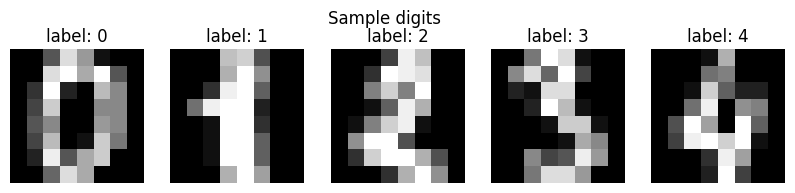

In [24]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

digits = load_digits()
X = digits.data     # (1797, 64) pixel intensities
y = digits.target   # (1797,) digit labels 0-9

fig, axes = plt.subplots(1, 5, figsize=(10, 2.2))
for ax, img, label in zip(axes, digits.images[:5], y[:5]):
    ax.imshow(img, cmap="gray")
    ax.set_title(f"label: {label}")
    ax.axis("off")
plt.suptitle("Sample digits")
plt.show()


In [25]:
torch.manual_seed(42)

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test  = torch.tensor(y_test, dtype=torch.long)

input_features = X_train.shape[1]        # 64 pixels
hidden1, hidden2 = 32, 16
output_classes = len(np.unique(y))       # 10 digits

model = DigitsClassifier(input_features, hidden1, hidden2, output_classes)
print(model)


DigitsClassifier(
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=16, bias=True)
  (out): Linear(in_features=16, out_features=10, bias=True)
)


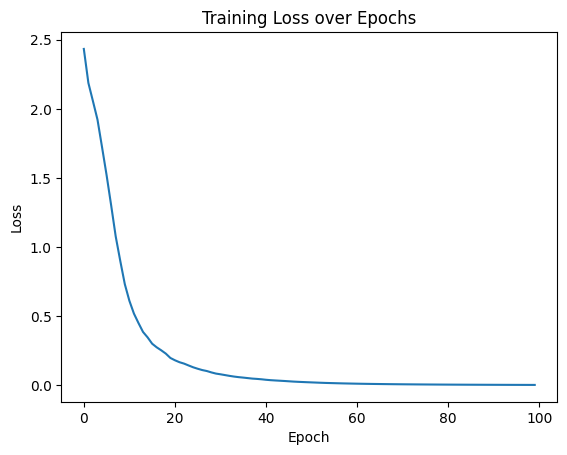

In [26]:
criterion = nn.CrossEntropyLoss()          # combines log-softmax + NLL loss for multi-class problems
optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 100
training_losses = []

for epoch in range(epochs):
    optimizer.zero_grad()                  # 1. clear old gradients
    predictions = model(X_train)           # 2. forward pass
    loss = criterion(predictions, y_train) # 3. compute loss
    loss.backward()                        # 4. backpropagate
    optimizer.step()                       # 5. update parameters

    training_losses.append(loss.item())

plt.plot(training_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss over Epochs")
plt.show()


In [27]:
# Evaluation: eval mode + no_grad, since we don't need dropout/batchnorm behavior or gradients
model.eval()
with torch.no_grad():
    test_predictions = model(X_test)
    predicted_labels = torch.argmax(test_predictions, dim=1)

correct_predictions = (predicted_labels == y_test).sum().item()
accuracy = correct_predictions / len(y_test) * 100
print(f"Test accuracy: {accuracy:.2f}%")


Test accuracy: 97.22%


**Why `model.eval()` and `torch.no_grad()`?**
- `model.eval()` switches layers like dropout/batch-norm to deterministic, inference-time behavior (not used in this simple model, but always good practice).
- `torch.no_grad()` disables gradient tracking during inference, saving memory and computation since we're not calling `.backward()`.


## 10. Project 3 — Challenge: Iris Flower Classification

A second full pipeline, this time on the classic **Iris** dataset (4 features, 3 species) — a compact way to confirm you can reproduce the whole workflow independently: split → tensors → model → train → evaluate.


In [28]:
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data
y = iris.target

torch.manual_seed(42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor  = torch.tensor(y_test, dtype=torch.long)


class IrisModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


input_size = X.shape[1]
output_size = len(np.unique(y))
model_iris = IrisModel(input_size=input_size, hidden_size=16, output_size=output_size)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_iris.parameters(), lr=0.01)

epochs = 100
for epoch in range(epochs):
    optimizer.zero_grad()
    y_pred = model_iris(X_train_tensor)
    loss = criterion(y_pred, y_train_tensor)
    loss.backward()
    optimizer.step()
    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

model_iris.eval()
with torch.no_grad():
    y_test_pred = model_iris(X_test_tensor)
    y_test_pred_labels = torch.argmax(y_test_pred, dim=1)

accuracy = (y_test_pred_labels == y_test_tensor).sum().item() / len(y_test) * 100
print(f"\nTest accuracy: {accuracy:.2f}%")


Epoch 0, Loss: 1.2547
Epoch 20, Loss: 0.6115
Epoch 40, Loss: 0.3671
Epoch 60, Loss: 0.2043
Epoch 80, Loss: 0.1231

Test accuracy: 100.00%


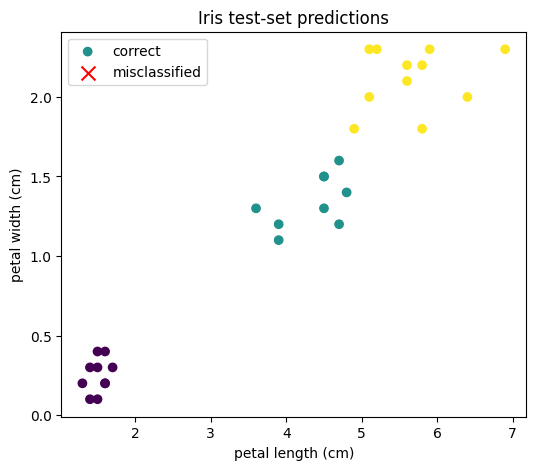

In [29]:
# Visualize predictions vs. ground truth on the two most informative features
plt.figure(figsize=(6, 5))
correct = (y_test_pred_labels == y_test_tensor)
plt.scatter(X_test[correct, 2], X_test[correct, 3], c=y_test[correct], cmap="viridis", label="correct", marker="o")
plt.scatter(X_test[~correct.numpy(), 2], X_test[~correct.numpy(), 3], c="red", marker="x", s=100, label="misclassified")
plt.xlabel(iris.feature_names[2])
plt.ylabel(iris.feature_names[3])
plt.title("Iris test-set predictions")
plt.legend()
plt.show()


## 11. Wrap-up & Key Takeaways

- **Tensors** are PyTorch's core n-dimensional array, similar to NumPy but with GPU support and autograd integration.
- **`torch.zeros/ones/arange/linspace/rand/randn/randint`** cover most initialization needs; real models use scaled initializations (Xavier/He) rather than raw uniform or integer values.
- **`view`/`reshape`/`unsqueeze`/`squeeze`** let you reshape tensors without changing their data — essential for feeding data into layers with specific expected shapes.
- **Autograd** (`requires_grad=True`, `.backward()`, `.grad`) automatically computes gradients via the chain rule — the mathematical engine behind every training loop.
- **The training loop** is always the same five-step rhythm:
  `forward → loss → zero_grad → backward → step`
- **`nn.Module`** is the base class for all custom models; you define layers in `__init__` and data flow in `forward`.
- **`TensorDataset` + `DataLoader`** simplify batching and shuffling.
- **`model.eval()` + `torch.no_grad()`** are essential during evaluation/inference.

With these building blocks, you can assemble virtually any deep learning model — from a one-line linear regressor to large transformer architectures — using the exact same primitives demonstrated in this notebook.
